# Brisque × Moth Atlas: building a quantum game with real quantum hardware

**Brisque** is a browser strategy game in the spirit of *Risk*, where armies can exist in **superposition**:
a split army is in two places at once, battles stay undecided until something *measures* them, and every
undecided outcome is finally settled by a genuine quantum measurement. It was built for **Moth Hack 2026**.
Play it at <https://brisque.noelnegash.workers.dev>.

This notebook is the workflow behind that, run end to end against the **Moth Atlas API**. It is written for two
audiences at once:

* **developers**, who want to see how a game turns into circuits, jobs and data files (every API call here is the same
  one the game makes);
* **curious non-physicists**, who want to know what "superposition", "measurement", "certified randomness" and
  "entanglement" actually mean. Each section opens with a plain-language box.

| § | What we do | Moth engine | Mode |
|---|---|---|---|
| 1 | Set up a tiny, honest job client: submit, poll, fetch, time every phase | – | – |
| 2 | Turn a battle into a quantum circuit (and export the exact OpenQASM the game sends) | – | local |
| 3 | Run a 3-army battle 1024 times, then one single *live collapse* like the game does | `tomography-api-v2` | emu |
| 4 | Certified hardware randomness: what ships inside the game | `comet-qrng-v1` | qpu pool + 1 emu job |
| 5 | Entanglement between territories | `graph-v1` | emu |
| 6 | The whole pipeline: how all of this reaches a player's browser | – | – |
| 7 | A quantum coin decides who moves first | `coin-toss-v1` | emu |

**Budget.** Every Moth job costs credits and takes 5 s to 3 min (mostly queue time). This notebook submits
**at most 5 jobs**, all on the emulator, and caches each result in `notebook/runs/`, so re-running it replays the
cached results instead of spending credits again (set `BRISQUE_FORCE_LIVE=1` to force new jobs).

## 1. Setup: a small, honest Moth client

> **In plain words.** A quantum computer is not something you call like a normal function. You *submit* a job, it
> waits in a **queue** with everyone else's, it **runs**, and later you **fetch** the result. Moth has no
> push notifications, so we *poll*: we ask "done yet?" with growing pauses in between (backoff), which keeps us well
> under the 300 requests/minute limit. We time every phase, because for a game the waiting is the hard part.

The API key is read from the `MOTH_API_KEY` environment variable or from the shared `.env` two folders up. It is
**never printed and never stored in this notebook**: it only lives in a request header inside the `requests` session.

In [1]:
import os, json, time, math, hashlib, shutil, subprocess
from decimal import Decimal
from pathlib import Path
import numpy as np
import requests
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'font.size': 10, 'axes.titleweight': 'bold'})
INK, MUTED = '#2b2b3a', '#8a8aa0'
C_TARGET, C_MEASURED, C_ACCENT, C_WARN = '#9db4e8', '#e8836b', '#6bbf8a', '#e2b04a'

NB_DIR = Path.cwd()
if not (NB_DIR / 'brisque_moth_workflow.ipynb').exists() and (NB_DIR / 'notebook').exists():
    NB_DIR = NB_DIR / 'notebook'
REPO = NB_DIR.parent                       # brisque/
RUNS = NB_DIR / 'runs'; RUNS.mkdir(exist_ok=True)

def load_key():
    if os.environ.get('MOTH_API_KEY'):
        return os.environ['MOTH_API_KEY'].strip(), 'environment'
    for env in [REPO.parent / '.env', REPO / '.env']:
        if env.exists():
            for line in env.read_text(encoding='utf-8').splitlines():
                if line.strip().startswith('MOTH_API_KEY') and '=' in line:
                    return line.split('=', 1)[1].strip().strip('"').strip("'"), env.name + ' file'
    return None, None

_key, _key_source = load_key() if os.environ.get('BRISQUE_OFFLINE') != '1' else (None, None)
MOTH_API = 'https://api.mothquantum.com/api/v1'
FORCE_LIVE = os.environ.get('BRISQUE_FORCE_LIVE') == '1'       # re-submit every job
RETRY_FAILED = os.environ.get('BRISQUE_RETRY_FAILED') == '1'   # re-submit only jobs whose cached attempt failed
MAX_JOBS = 8                               # hard ceiling for one execution of this notebook

_session = requests.Session()
if _key:
    _session.headers['Authorization'] = 'Bearer ' + _key
_session.headers['Content-Type'] = 'application/json'
del _key                                   # the session is the only place it lives now

print('Moth key:', f'loaded from {_key_source} (hidden)' if _key_source else 'not found, cached results only')
print('Repo:', REPO.name, '| cache dir:', RUNS.relative_to(REPO))

Moth key: loaded from .env file (hidden)
Repo: brisque | cache dir: notebook\runs


In [2]:
JOB_LOG = []          # every job this notebook touches, for the summary at the end
_jobs_submitted = 0

def _call(method, path, **kw):
    r = _session.request(method, MOTH_API + path, timeout=30, **kw)
    try:
        body = r.json()
    except ValueError:
        body = {}
    if not r.ok:   # report status + Moth's message only, never request headers
        msg = body.get('detail') or body.get('title') or body.get('error') or r.reason
        raise RuntimeError(f'Moth {r.status_code} on {path}: {msg}')
    return body

def run_job(label, engine, params, timeout_s=240):
    '''Submit -> poll with backoff -> fetch. Returns a record with result + per-phase timings.
    Cached in runs/<label>.json so re-executing the notebook never re-spends credits.'''
    global _jobs_submitted
    cache = RUNS / f'{label}.json'
    rec = json.loads(cache.read_text(encoding='utf-8')) if cache.exists() else None
    if rec and not FORCE_LIVE and (rec['status'] == 'completed' or not RETRY_FAILED):
        rec['replayed'] = True
        if rec.get('error'): print(f'[{label}] cached failure: {rec["error"]}')
        JOB_LOG.append(rec)
        print(f'[{label}] replayed from cache (job {rec.get("job_id")}, ran {rec.get("ran_at")}, status {rec["status"]})')
        return rec
    rec = {'label': label, 'engine': engine, 'params': params, 'job_id': None, 'status': 'not-run',
           'timings': {}, 'timeline': [], 'result': None, 'error': None,
           'ran_at': time.strftime('%Y-%m-%dT%H:%M:%S%z')}
    if 'Authorization' not in _session.headers:
        rec['error'] = 'no MOTH_API_KEY and no cached result'
        JOB_LOG.append(rec); print(f'[{label}] skipped: {rec["error"]}'); return rec
    if _jobs_submitted >= MAX_JOBS:
        rec['error'] = f'job budget of {MAX_JOBS} reached'
        JOB_LOG.append(rec); print(f'[{label}] skipped: {rec["error"]}'); return rec
    t0 = time.perf_counter()
    mark = lambda: round(time.perf_counter() - t0, 3)
    try:
        job = _call('POST', f'/engines/{engine}/process', json={'params': params})
        _jobs_submitted += 1
        rec['job_id'] = job['job_id']
        rec['timings']['submit_s'] = mark()
        rec['timeline'].append(('submitted', rec['timings']['submit_s']))
        print(f'[{label}] submitted job {job["job_id"]} in {rec["timings"]["submit_s"]:.2f} s')
        delay, last = 0.5, 'queued'
        while True:
            if time.perf_counter() - t0 > timeout_s:
                raise TimeoutError(f'still {last} after {timeout_s} s')
            time.sleep(delay)
            delay = min(5.0, delay * 1.4)          # backoff: fast for short emu jobs, gentle for long queues
            st = _call('GET', f'/jobs/{job["job_id"]}/status')
            s = st.get('status')
            if s != last:
                rec['timeline'].append((s, mark())); last = s
                print(f'  {mark():7.2f} s  {s}')
            if s == 'completed':
                break
            if s in ('failed', 'cancelled'):
                err = st.get('error') or {}
                raise RuntimeError(f'job {s}: {err.get("type", "")} {err.get("message", "")}'.strip())
        t_done = mark()
        res = _call('GET', f'/jobs/{job["job_id"]}/result')
        rec['result'] = res.get('result', res)
        rec['status'] = 'completed'
        rec['timings']['fetch_s'] = round(mark() - t_done, 3)
    except Exception as e:                          # graceful: keep going, record what happened
        rec['status'] = rec['status'] if rec['status'] == 'completed' else 'error'
        rec['error'] = str(e)
        print(f'[{label}] ERROR: {e}')
    rec['timings']['total_s'] = mark()
    tl = dict(rec['timeline'])
    if 'processing' in tl:
        rec['timings']['queued_s'] = round(tl['processing'] - tl.get('submitted', 0), 3)
        if 'completed' in tl:
            rec['timings']['processing_s'] = round(tl['completed'] - tl['processing'], 3)
    print(f'[{label}] {rec["status"]} | ' + ', '.join(f'{k} {v:.2f}s' for k, v in rec['timings'].items()))
    if rec['job_id']:   # cache successes AND Moth-side failures, so re-running never re-spends credits
        cache.write_text(json.dumps(rec, indent=1), encoding='utf-8')
    JOB_LOG.append(rec)
    return rec

def result_of(rec):
    '''engine JSON, unwrapping the optional {"output": ...} envelope'''
    r = rec.get('result') or {}
    return r['output'] if isinstance(r, dict) and isinstance(r.get('output'), dict) else r

## 2. Battles as circuits

> **In plain words.** In Brisque, when two armies meet in a territory, the battle is **not decided** right away.
> The territory sits in a *superposition* of "red won" and "blue won", with odds proportional to troop counts
> (9 troops against 8 is roughly 53/47). It stays undecided until a player **measures** it (with a bomb), and only then
> does reality pick one outcome.
>
> A qubit is the perfect container for that. It can be rotated to *any* mix of 0 and 1. If we rotate it by an angle θ
> around the Y axis (a gate called **RY(θ)**), measuring it gives 1 with probability sin²(θ/2). So to get "blue wins
> with probability p" we choose
>
> $$\theta = 2\,\arcsin\sqrt{p}.$$
>
> **A two-army battle is literally one quantum gate.**

For more outcomes (three armies, or a territory whose *contents* are themselves uncertain) we need
⌈log₂ K⌉ qubits and a recipe that loads K probabilities into their amplitudes. Brisque uses the
**Möttönen et al. (2004)** construction: decide the most significant bit first with one RY, then the next bit with
rotations *conditioned* on the bits already decided (uniformly-controlled RY, built from RY + CNOT in Gray-code
order). Below is a line-by-line Python port of the game's `src/shared/quantum/sampler.js` and `circuit.js`.

In [3]:
class Circuit:
    '''Python twin of src/shared/quantum/circuit.js: plain list of ops, exportable to OpenQASM 2.'''
    def __init__(self, n):
        self.num_qubits, self.ops = n, []
    def add(self, gate, qubits, params=()):
        self.ops.append({'gate': gate, 'qubits': list(qubits), 'params': list(params)}); return self
    def ry(self, theta, q): return self.add('ry', [q], [theta])
    def cx(self, c, t):     return self.add('cx', [c, t])
    def to_json(self):      return {'numQubits': self.num_qubits, 'ops': self.ops}
    def to_qasm(self):
        lines = ['OPENQASM 2.0;', 'include "qelib1.inc";', f'qreg q[{self.num_qubits}];', f'creg c[{self.num_qubits}];']
        for op in self.ops:
            p = f'({",".join(js_num(x) for x in op["params"])})' if op['params'] else ''
            lines.append(f'{op["gate"]}{p} ' + ','.join(f'q[{q}]' for q in op['qubits']) + ';')
        lines.append('measure q -> c;')
        return '\n'.join(lines)

def js_num(x):
    '''format a float exactly like JavaScript's Number#toString (shortest round-trip), so QASM is byte-identical'''
    if float(x).is_integer() and abs(x) < 1e21:
        return str(int(x))
    s = repr(float(x))
    if 'e' in s and 1e-7 <= abs(x) < 1e21:
        s = format(Decimal(s), 'f')                    # JS stays positional down to 1e-7
    elif 'e' in s:
        mant, exp = s.split('e'); s = f'{mant}e{"+" if int(exp) > 0 else "-"}{abs(int(exp))}'
    return s

def encode_distribution(probs):
    '''Port of encodeDistribution(): amplitudes sqrt(p_i) on m = ceil(log2 K) qubits; qubit t holds bit t.'''
    K = len(probs); m = max(1, math.ceil(math.log2(K))); N = 1 << m
    total = sum(probs)
    p = [probs[i] / total if i < K else 0.0 for i in range(N)]
    c = Circuit(m)
    for t in range(m - 1, -1, -1):                     # most significant bit first
        k = m - 1 - t                                  # controls: qubits t+1 .. m-1
        alphas = []
        for j in range(1 << k):
            lo = j << (t + 1); mid = lo + (1 << t); hi = lo + (1 << (t + 1))
            node = sum(p[lo:hi]); one = sum(p[mid:hi])
            alphas.append(2 * math.asin(math.sqrt(min(1.0, one / node))) if node > 1e-15 else 0.0)
        uniformly_controlled_ry(c, t, [t + 1 + i for i in range(k)], alphas)
    return c

def uniformly_controlled_ry(c, target, controls, alphas):
    k = len(controls)
    if k == 0:
        if abs(alphas[0]) > 1e-12: c.ry(alphas[0], target)
        return
    n = 1 << k
    gray = lambda i: i ^ (i >> 1)
    parity = lambda x: bin(x).count('1') & 1
    for i in range(n):
        theta = sum((-1 if parity(j & gray(i)) else 1) * alphas[j] for j in range(n))
        c.ry(theta / n, target)
        changed = gray(i) ^ gray((i + 1) % n)
        c.cx(controls[int(math.log2(changed))], target)

def pick_index(probs, u):
    '''inverse CDF, as in sampler.js pickIndex(): uniform u in [0,1) -> outcome index'''
    r = u * sum(probs)
    for i, p in enumerate(probs):
        if p > 0:
            r -= p
            if r < 0: return i
    return max(i for i, p in enumerate(probs) if p > 0)

A tiny exact **statevector simulator** lets us check the circuits before spending any credits. Bits are
*little-endian* (qubit 0 is the lowest bit of the outcome index), the same convention as the game's simulator and as
Moth's computational-basis counts, where the bitstring is printed with qubit 0 on the right.

In [4]:
def simulate(circ):
    psi = np.zeros(1 << circ.num_qubits); psi[0] = 1.0     # RY and CX keep amplitudes real
    idx = np.arange(len(psi))
    for op in circ.ops:
        if op['gate'] == 'ry':
            q = op['qubits'][0]; th = op['params'][0]; cs, sn = math.cos(th / 2), math.sin(th / 2)
            zero = idx[(idx >> q) & 1 == 0]; one = zero | (1 << q)
            a, b = psi[zero].copy(), psi[one].copy()
            psi[zero], psi[one] = cs * a - sn * b, sn * a + cs * b
        elif op['gate'] == 'cx':
            c, t = op['qubits']
            sel = idx[((idx >> c) & 1 == 1) & ((idx >> t) & 1 == 0)]
            psi[sel], psi[sel | (1 << t)] = psi[sel | (1 << t)].copy(), psi[sel].copy()
    return psi

# Two armies: 9 red troops attack 8 blue troops. Brisque: P(victor) is proportional to troops (battleExponent = 1).
red, blue = 9, 8
p_blue = blue / (red + blue)
c2 = encode_distribution([red, blue])
theta = c2.ops[0]['params'][0]
print(f'2-army battle {red} vs {blue}: P(blue) = {p_blue:.4f}')
print(f'  circuit = {len(c2.ops)} gate: RY({theta:.6f})   and 2*asin(sqrt(p)) = {2 * math.asin(math.sqrt(p_blue)):.6f}')
print(f'  simulated P(1) = {simulate(c2)[1] ** 2:.4f}')
print()
print(c2.to_qasm())

2-army battle 9 vs 8: P(blue) = 0.4706
  circuit = 1 gate: RY(1.511939)   and 2*asin(sqrt(p)) = 1.511939
  simulated P(1) = 0.4706

OPENQASM 2.0;
include "qelib1.inc";
qreg q[1];
creg c[1];
ry(1.5119388208478155) q[0];
measure q -> c;


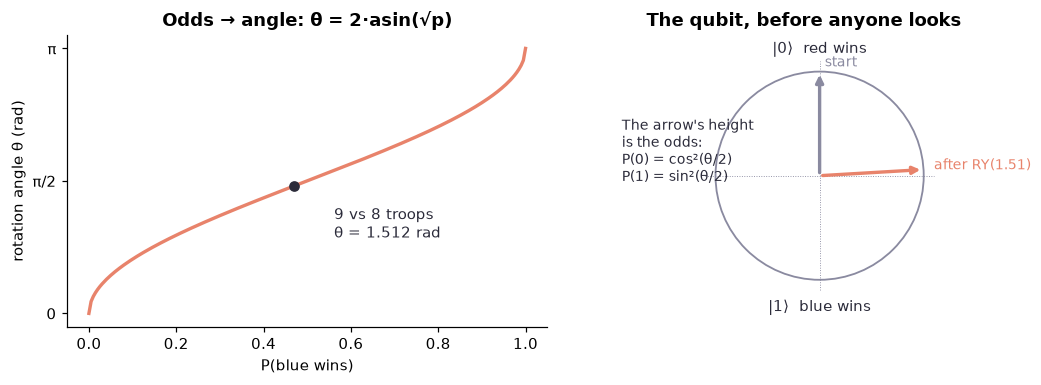

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
ps = np.linspace(0, 1, 201)
ax1.plot(ps, 2 * np.arcsin(np.sqrt(ps)), color=C_MEASURED, lw=2.2)
ax1.scatter([p_blue], [theta], color=INK, zorder=5)
ax1.annotate(f' 9 vs 8 troops\n θ = {theta:.3f} rad', (p_blue, theta), xytext=(0.55, 0.9), color=INK)
ax1.set(xlabel='P(blue wins)', ylabel='rotation angle θ (rad)', title='Odds → angle: θ = 2·asin(√p)',
        yticks=[0, math.pi / 2, math.pi], yticklabels=['0', 'π/2', 'π'])

# the qubit's state on the X-Z great circle of the Bloch sphere
ax2.set_aspect('equal'); ax2.axis('off')
ax2.add_patch(Circle((0, 0), 1, fill=False, color=MUTED, lw=1.2))
ax2.plot([-1.1, 1.1], [0, 0], color=MUTED, lw=0.6, ls=':'); ax2.plot([0, 0], [-1.1, 1.1], color=MUTED, lw=0.6, ls=':')
ax2.text(0, 1.18, '|0⟩  red wins', ha='center', color=INK); ax2.text(0, -1.3, '|1⟩  blue wins', ha='center', color=INK)
for th, col, lab in [(0, MUTED, 'start'), (theta, C_MEASURED, f'after RY({theta:.2f})')]:
    ax2.annotate('', xy=(math.sin(th), math.cos(th)), xytext=(0, 0),
                 arrowprops=dict(arrowstyle='-|>', color=col, lw=2.2))
    ax2.text(1.05 * math.sin(th) + 0.05, 1.05 * math.cos(th), lab, color=col, fontsize=9)
ax2.text(-1.9, -0.05, 'The arrow\'s height\nis the odds:\nP(0) = cos²(θ/2)\nP(1) = sin²(θ/2)', fontsize=9, color=INK)
ax2.set_xlim(-2, 1.7); ax2.set_ylim(-1.45, 1.35)
ax2.set_title('The qubit, before anyone looks')
plt.tight_layout(); plt.show()

### Three armies need two qubits

A three-way battle with **9, 8 and 1** troops has odds 50% / 44.4% / 5.6%. Two qubits give four basis states
(`00 01 10 11`), and the encoder leaves `11` at exactly zero. The circuit decides the high bit (army 2 vs the rest)
with one RY, then the low bit with a *uniformly controlled* RY on qubit 0: two RYs and two CNOTs.

  outcome 0 (bits 00): target 0.5000   simulated 0.5000
  outcome 1 (bits 01): target 0.4444   simulated 0.4444
  outcome 2 (bits 10): target 0.0556   simulated 0.0556
  outcome 3 (bits 11): target 0.0000   simulated 0.0000


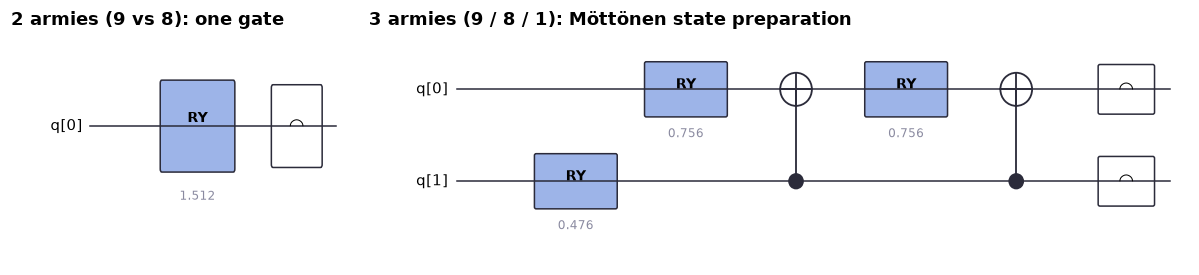

OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[2];
ry(0.47588224966041653) q[1];
ry(0.7559694104239078) q[0];
cx q[1],q[0];
ry(0.7559694104239078) q[0];
cx q[1],q[0];
measure q -> c;


In [6]:
battle3 = [9, 8, 1]
c3 = encode_distribution(battle3)
target3 = np.array(battle3 + [0]) / sum(battle3)
probs3 = simulate(c3) ** 2
for i in range(4):
    print(f'  outcome {i} (bits {i:02b}): target {target3[i]:.4f}   simulated {probs3[i]:.4f}')

def draw_circuit(circ, title, ax=None, labels=None):
    ax = ax or plt.gca(); n = circ.num_qubits; step = 1.25
    x_end = 1 + step * (len(circ.ops) + 1)
    for q in range(n):
        y = n - 1 - q
        ax.plot([0.4, x_end], [y, y], color=INK, lw=1)
        ax.text(0.3, y, labels[q] if labels else f'q[{q}]', ha='right', va='center', fontsize=10)
    for i, op in enumerate(circ.ops):
        x = 1 + step * (i + 0.6)
        if op['gate'] == 'ry':
            y = n - 1 - op['qubits'][0]
            ax.add_patch(FancyBboxPatch((x - 0.45, y - 0.28), 0.9, 0.56, boxstyle='round,pad=0.02',
                                        fc=C_TARGET, ec=INK, lw=1))
            ax.text(x, y + 0.05, 'RY', ha='center', va='center', fontsize=9, weight='bold')
            ax.text(x, y - 0.42, f'{op["params"][0]:.3f}', ha='center', va='top', fontsize=8, color=MUTED)
        elif op['gate'] == 'cx':
            yc, yt = n - 1 - op['qubits'][0], n - 1 - op['qubits'][1]
            ax.plot([x, x], [yc, yt], color=INK, lw=1.2)
            ax.add_patch(Circle((x, yc), 0.08, color=INK))
            ax.add_patch(Circle((x, yt), 0.18, fill=False, ec=INK, lw=1.2))
            ax.plot([x - 0.18, x + 0.18], [yt, yt], color=INK, lw=1.2); ax.plot([x, x], [yt - 0.18, yt + 0.18], color=INK, lw=1.2)
    xm = x_end - 0.5
    for q in range(n):
        y = n - 1 - q
        ax.add_patch(FancyBboxPatch((xm - 0.3, y - 0.25), 0.6, 0.5, boxstyle='round,pad=0.02', fc='white', ec=INK))
        ax.text(xm, y, '◠', ha='center', va='center', fontsize=12)
    ax.set_xlim(-0.6, x_end + 0.2); ax.set_ylim(-0.9, n - 0.4); ax.axis('off'); ax.set_title(title, loc='left')

fig, axes = plt.subplots(1, 2, figsize=(11, 2.6), gridspec_kw={'width_ratios': [1, 2.4]})
draw_circuit(c2, '2 armies (9 vs 8): one gate', axes[0])
draw_circuit(c3, '3 armies (9 / 8 / 1): Möttönen state preparation', axes[1])
plt.tight_layout(); plt.show()
QASM3 = c3.to_qasm()
print(QASM3)

**Check against the game.** If Node.js is available, we ask the game's own JavaScript encoder for the same
battles and compare the OpenQASM strings: the circuits this notebook sends to Moth are the circuits a match sends.
(For bigger battles an angle can differ in its 16th digit, because JavaScript and C round `asin` differently.)

In [7]:
node = shutil.which('node')
if node:
    js = ("import { encodeDistribution } from './src/shared/quantum/sampler.js';"
          "for (const p of [[9,8],[9,8,1],[5,3,2,1,1]]) console.log(JSON.stringify(encodeDistribution(p).circuit.toQASM()));")
    try:
        out = subprocess.run([node, '--input-type=module', '-e', js], cwd=REPO, capture_output=True, text=True, timeout=60)
        js_qasm = [json.loads(l) for l in out.stdout.strip().splitlines()]
        import re
        num = lambda s: [float(x) for x in re.findall(r'\(([^)]*)\)', s)]
        for p, q in zip([[9, 8], [9, 8, 1], [5, 3, 2, 1, 1]], js_qasm):
            mine = encode_distribution(p).to_qasm()
            if q == mine:
                print(f'{str(p):18s} byte-identical QASM ({len(mine.splitlines()) - 5} gates)')
            else:   # same gate list; angles may differ in the last digit (V8 vs C libm asin/sqrt rounding)
                gates = [re.sub(r'\(.*?\)', '', l) for l in q.splitlines()] == [re.sub(r'\(.*?\)', '', l) for l in mine.splitlines()]
                diff = max(abs(a - b) for a, b in zip(num(q), num(mine)))
                print(f'{str(p):18s} same gates: {gates}, max angle difference {diff:.1e} rad (last-digit float rounding)')
    except Exception as e:
        print('Node comparison skipped:', e)
else:
    print('Node.js not found; skipping the cross-check.')

[9, 8]             byte-identical QASM (1 gates)
[9, 8, 1]          byte-identical QASM (5 gates)
[5, 3, 2, 1, 1]    same gates: True, max angle difference 1.1e-16 rad (last-digit float rounding)


## 3. Running a battle on Moth: `tomography-api-v2`

> **In plain words.** Quantum mechanics only ever gives you *probabilities*. One measurement of the battle qubit
> gives one winner, and you can't tell from a single shot whether the odds were 50/50 or 99/1. To *see* the odds we
> prepare the identical battle many times and count. With 1024 repetitions ("shots") the counts should land close to
> 50 / 44 / 6, within a few percent of statistical noise.

Moth has no "just run my circuit" endpoint, but `tomography-api-v2` accepts arbitrary OpenQASM 2 and reports
measurement counts in several bases. Any basis key made only of `I`/`Z` (here `ZZ`) holds ordinary
computational-basis samples. That's what the game reads.

In [8]:
tomo_params = lambda qasm, shots: {'circuit_qasm': qasm, 'shots': shots, 'double_tomography': False,
                                   'mutual_information': False, 'classical_mutual_information': False}
rec_hist = run_job('tomography-3army-1024', 'tomography-api-v2', tomo_params(QASM3, 1024))

def z_counts(result):
    meas = (result or {}).get('measurements', {})
    key = next((k for k in meas if set(k) <= {'I', 'Z'}), None)
    return (meas[key]['counts'], key) if key else ({}, None)

[tomography-3army-1024] cached failure: job failed: engine_timeout The engine did not respond in time — retry the job
[tomography-3army-1024] replayed from cache (job 57115e9b-0959-4972-beeb-0602cf724430, ran 2026-10-05T22:55+0300, status error)


Live job unavailable (job failed: engine_timeout The engine did not respond in time — retry the job).
Showing the archived run of the same QASM from tools/moth/bench-2026-09-25.json instead.



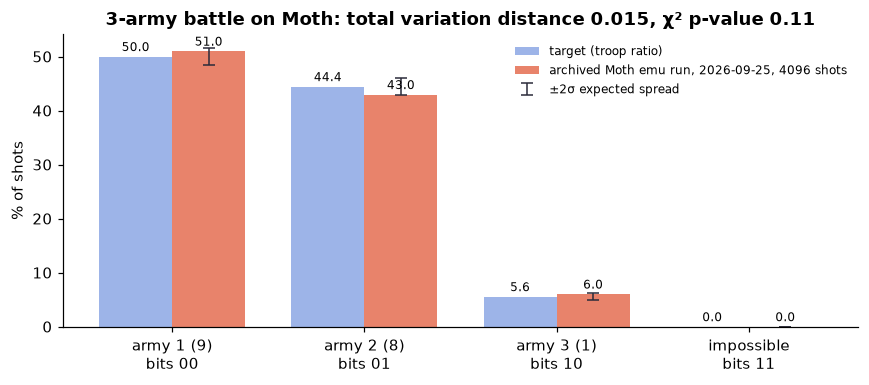

basis key ZZ; raw counts {'10': 247, '00': 2089, '01': 1760}
For reference, on 2026-09-25 a 4096-shot run measured 51 / 43 / 6 against the same 50 / 44 / 6 target.


In [9]:
counts, key = z_counts(result_of(rec_hist))
source = f'Moth emu, job {str(rec_hist.get("job_id"))[:8]}'
hist_result = result_of(rec_hist)
if not counts:
    # live job failed (Moth-side queue/engine timeouts happen): show our archived run of the identical circuit instead
    bench = REPO / 'tools/moth/bench-2026-09-25.json'
    if bench.exists():
        run = next((r for r in json.loads(bench.read_text())['runs'] if r['label'] == 'tomography emu 4096'), None)
        if run and run.get('status') == 'completed':
            hist_result = run['result']; counts, key = z_counts(hist_result)
            source = 'archived Moth emu run, 2026-09-25'
            print(f'Live job unavailable ({rec_hist.get("error")}).\nShowing the archived run of the same QASM from tools/moth/bench-2026-09-25.json instead.\n')
if counts:
    shots = sum(counts.values())
    measured = np.array([counts.get(format(i, '02b'), 0) for i in range(4)]) / shots   # '01' -> index 1
    tvd = 0.5 * np.abs(measured - target3).sum()
    # chi-square goodness of fit on the 3 possible outcomes (2 degrees of freedom: p-value = exp(-chi2/2))
    exp_c = target3[:3] * shots; obs_c = measured[:3] * shots
    chi2 = float(((obs_c - exp_c) ** 2 / exp_c).sum()); pval = math.exp(-chi2 / 2)

    fig, ax = plt.subplots(figsize=(8, 3.6))
    x = np.arange(4); w = 0.38
    labels = ['army 1 (9)\nbits 00', 'army 2 (8)\nbits 01', 'army 3 (1)\nbits 10', 'impossible\nbits 11']
    b1 = ax.bar(x - w / 2, target3 * 100, w, color=C_TARGET, label='target (troop ratio)')
    b2 = ax.bar(x + w / 2, measured * 100, w, color=C_MEASURED, label=f'{source}, {shots} shots')
    sigma = np.sqrt(target3 * (1 - target3) / shots) * 100
    ax.errorbar(x + w / 2, target3 * 100, yerr=2 * sigma, fmt='none', ecolor=INK, capsize=4, lw=1, label='±2σ expected spread')
    for bars in (b1, b2):
        for b in bars: ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1, f'{b.get_height():.1f}', ha='center', fontsize=8)
    ax.set_xticks(x, labels); ax.set_ylabel('% of shots'); ax.legend(frameon=False, fontsize=8)
    ax.set_title(f'3-army battle on Moth: total variation distance {tvd:.3f}, χ² p-value {pval:.2f}')
    plt.tight_layout(); plt.show()
    print(f'basis key {key}; raw counts {counts}')
    print('For reference, on 2026-09-25 a 4096-shot run measured 51 / 43 / 6 against the same 50 / 44 / 6 target.')
else:
    print('No counts available (job failed or skipped):', rec_hist.get('error'))

**What tomography adds.** The same job also measured each qubit in the X and Y bases and reconstructed each qubit's
*Bloch vector* (`observables`). Our simulator predicts those exactly, so we can compare the quantum state itself,
not just the odds.

In [10]:
def bloch_from_state(psi, n):
    '''per-qubit <X>, <Y>, <Z> for a real statevector, little-endian'''
    out = {}
    idx = np.arange(len(psi))
    for q in range(n):
        zero = idx[(idx >> q) & 1 == 0]; one = zero | (1 << q)
        z = float((psi[zero] ** 2).sum() - (psi[one] ** 2).sum())
        x = float(2 * (psi[zero] * psi[one]).sum())
        out[q] = {'X': x, 'Y': 0.0, 'Z': z}
    return out

obs = (hist_result or {}).get('observables') if counts else None
pred = bloch_from_state(simulate(c3), 2)
if obs:
    print('qubit  basis   predicted   Moth')
    for q in range(2):
        for b in 'XYZ':
            print(f'  {q}      {b}     {pred[q][b]:+.3f}     {obs[str(q)][b]:+.3f}')
else:
    print('no observables in result')

qubit  basis   predicted   Moth
  0      X     +0.943     +0.937
  0      Y     +0.000     +0.006
  0      Z     +0.111     +0.141
  1      X     +0.333     +0.333
  1      Y     +0.000     +0.011
  1      Z     +0.889     +0.879


### One live collapse, exactly as the game does it

During a match a collapse is **one shot**: the circuit runs once and whatever comes out *is* the outcome. Below is
that call with the time spent in each phase. This is the reason the game does not wait for a live job on every
move (see §4 and §6): the queue, not the quantum computer, sets the pace.

[tomography-3army-1shot] cached failure: job failed: engine_timeout The engine did not respond in time — retry the job
[tomography-3army-1shot] replayed from cache (job 595390f2-a2a2-4b1e-aa27-7a0f89a7cdff, ran 2026-10-05T22:55+0300, status error)
Live collapse failed (job failed: engine_timeout The engine did not respond in time — retry the job).
In a match the sampler would now fall back to the QPU pool (§4) instantly. Below: our archived 1-shot run of the same circuit.


Measured bitstring 00 -> outcome 0: army 1 (9 troops) holds the territory.


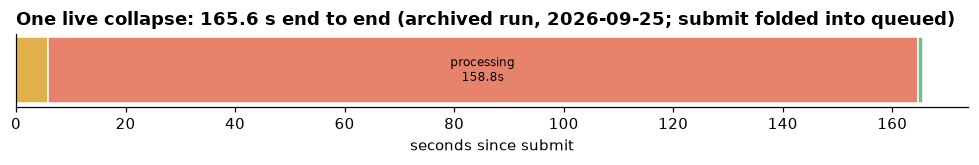

In [11]:
rec_live = run_job('tomography-3army-1shot', 'tomography-api-v2', tomo_params(QASM3, 1))
counts1, _ = z_counts(result_of(rec_live))
live_note = f'job {str(rec_live.get("job_id"))[:8]}…'
if not counts1:
    print(f'Live collapse failed ({rec_live.get("error")}).')
    print('In a match the sampler would now fall back to the QPU pool (§4) instantly. Below: our archived 1-shot run of the same circuit.\n')
    bench = REPO / 'tools/moth/bench-2026-09-25.json'
    run = next((r for r in json.loads(bench.read_text())['runs'] if r['label'] == 'tomography emu 1 shot'), None) if bench.exists() else None
    if run and run.get('status') == 'completed':
        counts1, _ = z_counts(run['result'])
        tl = {e['status']: e['at'] / 1000 for e in run['timeline']}
        rec_live = dict(rec_live, timings={'submit_s': 0.0, 'queued_s': tl.get('processing', 0),
                                           'processing_s': tl['completed'] - tl.get('processing', 0),
                                           'fetch_s': run['ms'] / 1000 - tl['completed'], 'total_s': run['ms'] / 1000})
        live_note = 'archived run, 2026-09-25; submit folded into queued'
if counts1:
    bits = next(iter(counts1)); idx = int(bits, 2)
    print(f'\nMeasured bitstring {bits} -> outcome {idx}: army {idx + 1} ({battle3[idx]} troops) holds the territory.')
    tm = rec_live['timings']
    phases = [('submit', tm.get('submit_s', 0)), ('queued', tm.get('queued_s', 0)),
              ('processing', tm.get('processing_s', 0)), ('fetch', tm.get('fetch_s', 0))]
    fig, ax = plt.subplots(figsize=(9, 1.6)); left = 0
    for (name, d), col in zip(phases, [MUTED, C_WARN, C_MEASURED, C_ACCENT]):
        ax.barh(0, d, left=left, color=col, edgecolor='white');
        if d > 0.04 * tm['total_s']: ax.text(left + d / 2, 0, f'{name}\n{d:.1f}s', ha='center', va='center', fontsize=8)
        left += d
    ax.set_yticks([]); ax.set_xlabel('seconds since submit')
    ax.set_title(f'One live collapse: {tm["total_s"]:.1f} s end to end ({live_note})', loc='left')
    plt.tight_layout(); plt.show()
else:
    print('No live or archived collapse available.')

## 4. Certified hardware randomness: `comet-qrng-v1`

> **In plain words.** Computers can't make true randomness; they *simulate* it with formulas that are, in
> principle, predictable. Quantum mechanics says some events are random **in principle**: when a qubit in an equal
> superposition is measured, nothing in the universe, not even the machine, knows the answer beforehand
> (this is the *Born rule*). So a real quantum chip is a natural dice-roller.
>
> But how do you *know* the chip was really behaving quantumly and wasn't just noisy electronics? Moth's
> **comet-qrng** engine adds three safeguards and a certificate:
>
> 1. **A Bell test.** Alongside the random qubits it entangles pairs and measures them at specially chosen angles.
>    Any classical, pre-arranged mechanism scores **S ≤ 2** on this test (the CHSH inequality); quantum entanglement
>    can reach **2√2 ≈ 2.83**. Scoring above 2 is evidence that the device was entangling for real.
> 2. **Min-entropy accounting.** Real hardware is slightly biased (a qubit might read 1 50.3% of the time). Comet
>    measures that and computes a conservative **min-entropy** *h*: how many truly unpredictable bits each raw
>    bit is worth (statistically estimated per NIST SP 800-90B).
> 3. **Randomness extraction.** A **Toeplitz hash** squeezes the long, slightly-biased raw bits into a shorter
>    string that is provably within 2⁻⁶⁴ of perfectly uniform (leftover hash lemma).
>
> A commitment hash is published *before* the outcome exists, and an output hash lets anyone check the bytes later.

**Why the game uses a pool.** A QPU job took 74–94 s. Nobody waits 90 s per battle. So we ran comet on real IBM
hardware *ahead of time* and shipped the certified bytes inside the game (`public/generated/qrng-qpu.json`). Every
collapse consumes 32 fresh QPU bits, instantly, with no key and no network. Let's open that file.

In [12]:
pool = json.loads((REPO / 'public/generated/qrng-qpu.json').read_text())
raw = bytes.fromhex(pool['hex'])
print(f"engine {pool['engine']} | mode {pool['mode']} | {len(raw):,} bytes = {len(raw) // 4:,} collapses | updated {pool['updated']}\n")
print(f"{'job':10s} {'backend':14s} {'bytes':>6s} {'wall s':>7s} {'QPU s':>6s} {'h/bit':>6s} {'Bell S':>7s}  grade                sha256 ok")
off = 0
for b in pool['batches']:
    chunk = raw[off: off + b['bytes']]; off += b['bytes']
    ok = hashlib.sha256(chunk).hexdigest() == b['output_hash']
    print(f"{b['job_id'][:8]:10s} {b['backend']:14s} {b['bytes']:6d} {b['seconds']:7.1f} {b['qpu_seconds']:6d} "
          f"{b['h_bit']:6.3f} {b['bell_S']:7.3f}  {b['grade']:20s} {ok}")
print('\nEvery batch\'s bytes hash to the output_hash in its certificate: the shipped pool is exactly what the QPU produced.')

engine comet-qrng-v1 | mode qpu | 24,199 bytes = 6,049 collapses | updated 2026-09-25T19:47:48.050Z

job        backend         bytes  wall s  QPU s  h/bit  Bell S  grade                sha256 ok
e251846a   ibm_marrakesh    4201    79.5      2  0.423   2.616  hardware-accounted   True
3a321462   ibm_marrakesh    4201    87.6      2  0.423   2.640  hardware-accounted   True
d9b2fb28   ibm_kingston     8179    87.9      2  0.741   2.376  hardware-accounted   True
7e9423f8   ibm_kingston     7618    87.7      2  0.696   2.452  hardware-accounted   True

Every batch's bytes hash to the output_hash in its certificate: the shipped pool is exactly what the QPU produced.


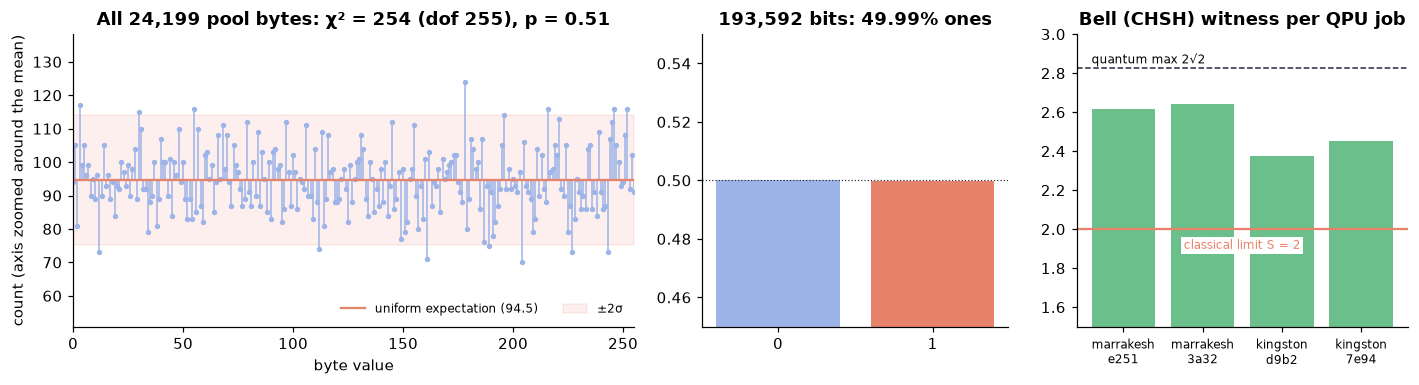

monobit z = -0.10, runs z = -0.03  (|z| < 3 means no detectable bias or streakiness)


In [13]:
arr = np.frombuffer(raw, dtype=np.uint8)
bits = np.unpackbits(arr)
counts256 = np.bincount(arr, minlength=256)
expected = len(arr) / 256
chi2 = float(((counts256 - expected) ** 2 / expected).sum()); dof = 255
# Wilson-Hilferty normal approximation to the chi-square tail (accurate for dof this large)
zwh = ((chi2 / dof) ** (1 / 3) - (1 - 2 / (9 * dof))) / math.sqrt(2 / (9 * dof))
p_chi = 0.5 * math.erfc(zwh / math.sqrt(2))
ones = bits.mean(); z_mono = (bits.sum() - len(bits) / 2) / math.sqrt(len(bits) / 4)
runs = 1 + int(np.count_nonzero(bits[1:] != bits[:-1]))
exp_runs = 1 + (len(bits) - 1) / 2; z_runs = (runs - exp_runs) / math.sqrt((len(bits) - 1) / 4)

S = [b['bell_S'] for b in pool['batches']]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), gridspec_kw={'width_ratios': [2.2, 1.2, 1.3]})
ax = axes[0]
sd = math.sqrt(expected)
ax.vlines(range(256), expected, counts256, color=C_TARGET, lw=1)
ax.plot(range(256), counts256, 'o', ms=2.5, color=C_TARGET)
ax.set_ylim(expected - 4.5 * sd, expected + 4.5 * sd)
ax.axhline(expected, color=C_MEASURED, lw=1.5, label=f'uniform expectation ({expected:.1f})')
ax.fill_between([0, 255], expected - 2 * math.sqrt(expected), expected + 2 * math.sqrt(expected), color=C_MEASURED, alpha=0.12, label='±2σ')
ax.set(xlim=(0, 255), xlabel='byte value', ylabel='count (axis zoomed around the mean)', title=f'All {len(arr):,} pool bytes: χ² = {chi2:.0f} (dof 255), p = {p_chi:.2f}')
ax.legend(frameon=False, fontsize=8, loc='lower right', ncol=2)
ax = axes[1]
ax.bar(['0', '1'], [1 - ones, ones], color=[C_TARGET, C_MEASURED]); ax.set_ylim(0.45, 0.55)
ax.set_title(f'{len(bits):,} bits: {ones * 100:.2f}% ones'); ax.axhline(0.5, color=INK, lw=0.8, ls=':')
ax = axes[2]
ax.bar([f"{b['backend'].replace('ibm_', '')}\n{b['job_id'][:4]}" for b in pool['batches']], S, color=C_ACCENT)
ax.axhline(2, color=C_MEASURED, lw=1.5); ax.text(1.5, 1.95, 'classical limit S = 2', color=C_MEASURED, fontsize=8, ha='center', va='top', bbox=dict(fc='white', ec='none', pad=1.5))
ax.axhline(2 * math.sqrt(2), color=INK, lw=1, ls='--'); ax.text(-0.4, 2.85, 'quantum max 2√2', fontsize=8)
ax.set_ylim(1.5, 3.0); ax.set_title('Bell (CHSH) witness per QPU job'); ax.tick_params(axis='x', labelsize=8)
plt.tight_layout(); plt.show()
print(f'monobit z = {z_mono:+.2f}, runs z = {z_runs:+.2f}  (|z| < 3 means no detectable bias or streakiness)')

### What the extractor does, in miniature

The raw hardware bits are *nearly* fair. Below we fake an exaggerated case: a coin that lands 1 **65% of the time**.
Its min-entropy is h = −log₂(0.65) ≈ 0.62 bits per flip: an adversary who always guesses "1" is right 65% of the
time, so each flip is worth only 0.62 truly unpredictable bits. A Toeplitz matrix (each row is the previous one
shifted by one, so a seed of n + m − 1 bits defines it) multiplies the n raw bits mod 2 down to m < h·n output bits.
The bias disappears. Comet does the same with tens of thousands of bits and a 2⁻⁶⁴ security margin.

256 raw bits, h = 0.621/bit -> 127 extracted bits per block (Toeplitz 127×256)
fraction of ones: raw 0.650   extracted 0.5007


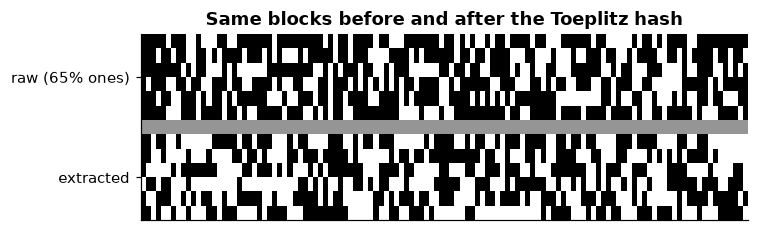

In [14]:
rng = np.random.default_rng(2026)
n_raw, bias = 256, 0.65
h = -math.log2(bias); m_out = int(h * n_raw) - 2 * 16          # leave a safety margin, like comet's 2·64
seed = rng.integers(0, 2, n_raw + m_out - 1)
T = np.array([[seed[i - j + n_raw - 1] for j in range(n_raw)] for i in range(m_out)], dtype=np.uint8)  # Toeplitz
blocks = 4000
raw_bits = (rng.random((blocks, n_raw)) < bias).astype(np.uint8)
out_bits = (raw_bits @ T.T) % 2
print(f'{n_raw} raw bits, h = {h:.3f}/bit -> {m_out} extracted bits per block (Toeplitz {m_out}×{n_raw})')
print(f'fraction of ones: raw {raw_bits.mean():.3f}   extracted {out_bits.mean():.4f}')
fig, ax = plt.subplots(figsize=(7, 2.2))
ax.imshow(np.vstack([raw_bits[:6, :120], np.full((1, 120), 0.5), out_bits[:6, :120]]), cmap='Greys', aspect='auto', interpolation='nearest')
ax.set_yticks([2.5, 9.5], ['raw (65% ones)', 'extracted']); ax.set_xticks([]); ax.set_title('Same blocks before and after the Toeplitz hash')
plt.tight_layout(); plt.show()

### From 32 quantum bits to a battle outcome

Each collapse takes the next 4 bytes of the pool as a 32-bit integer and divides by 2³² to get a uniform number
*u* in [0, 1). The odds are laid end to end on a line from 0 to 1 (the cumulative distribution), and *u* lands in
exactly one army's segment: the **inverse CDF**. A pool draw and a live one-shot circuit are mathematically the same
experiment: each picks outcome *i* with probability *pᵢ*.

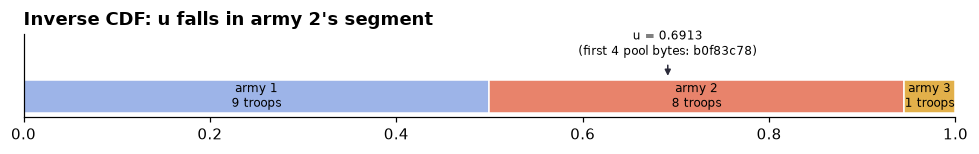

6,049 collapses from QPU randomness: army 1 50.4% (target 50.0%), army 2 43.7% (target 44.4%), army 3 6.0% (target 5.6%)


In [15]:
def pool_uniforms(raw, start=0):
    for i in range(start, len(raw) - 3, 4):
        yield int.from_bytes(raw[i:i + 4], 'big') / 2 ** 32     # same byte order as qrng.js

draws = list(pool_uniforms(raw))
u0 = draws[0]
cdf = np.cumsum([0] + list(np.array(battle3) / sum(battle3)))
fig, ax = plt.subplots(figsize=(9, 1.5))
for i in range(3):
    ax.barh(0, cdf[i + 1] - cdf[i], left=cdf[i], color=[C_TARGET, C_MEASURED, C_WARN][i], edgecolor='white')
    ax.text((cdf[i] + cdf[i + 1]) / 2, 0, f'army {i + 1}\n{battle3[i]} troops', ha='center', va='center', fontsize=8)
ax.annotate(f'u = {u0:.4f}\n(first 4 pool bytes: {raw[:4].hex()})', (u0, 0.42), xytext=(u0, 1.0), ha='center', fontsize=8,
            arrowprops=dict(arrowstyle='-|>', color=INK))
ax.set_xlim(0, 1); ax.set_ylim(-0.5, 1.5); ax.set_yticks([]); ax.set_title(f'Inverse CDF: u falls in army {pick_index(battle3, u0) + 1}\'s segment', loc='left')
plt.tight_layout(); plt.show()

# replay the 9 / 8 / 1 battle once per pool entry: thousands of collapses, all decided by IBM hardware
outcomes = np.bincount([pick_index(battle3, u) for u in draws], minlength=3)
print(f'{len(draws):,} collapses from QPU randomness: ' +
      ', '.join(f'army {i + 1} {outcomes[i] / len(draws) * 100:.1f}% (target {battle3[i] / sum(battle3) * 100:.1f}%)' for i in range(3)))

**For contrast, one small comet job on the emulator.** The emulator runs the same circuits on a classical
simulator, so its randomness is *pseudo*-random. Comet knows this and labels it honestly instead of certifying it.
(Note: comet reads aggregated counts, so shot order is lost and the extractor subtracts log₂(shots!) bits. Wide
registers with few shots, like the 100 × 1000 QPU runs above, are what yield kilobytes.)

In [16]:
rec_comet = run_job('comet-emu-small', 'comet-qrng-v1',
                    {'mode': 'emu', 'num_qubits': 20, 'shots': 1000, 'output_bytes': 64,
                     'bell_witness': False, 'include_raw_counts': False})
co = result_of(rec_comet)
if rec_comet['status'] == 'completed' and isinstance(co, dict):
    er, ent = co.get('entropy_report', {}), co.get('entropy', {})
    print('grade      :', er.get('grade'))
    print('h per bit  :', round(ent.get('h_bit', float('nan')), 4))
    print('bytes out  :', co.get('random', {}).get('bytes'), '| hex', (co.get('random', {}).get('hex') or '')[:32] + '…')
    print('backend    :', co.get('provenance', {}).get('backend'), '| commit', (co.get('commitment', {}).get('commit') or '')[:16] + '…')
    for s in er.get('statements', [])[:4]:
        print('  •', s)
else:
    print('comet emu job unavailable:', rec_comet.get('error'))

[comet-emu-small] replayed from cache (job 106fea75-4733-4559-8ecc-61746880b8c9, ran 2026-10-05T22:39:42+0300, status completed)
grade      : simulator-baseline
h per bit  : 0.7967
bytes out  : 64 | hex 243d9e81667db76677767484cc9d95f8…
backend    : aer | commit b2155e7311b35a52…
  • 20000 raw Born-rule bits from 20 qubits × 1000 shots (counts readout)
  • conservative per-bit min-entropy h = 0.7967 (SP 800-90B estimators at 99% confidence)
  • modelled budget = 7405.4 bits (no dependence beyond pairwise correlations — ASSUMED, tested only by collision consistency against the pairwise tree model: full-register z = -0.73, 0/512 sub-registers failed)
  • assumption-free budget = 0.0 bits (whole-shot most-common-value bound, 8.13 bits/shot; capped near log2(shots) by sample size)


## 5. Entanglement between territories: `graph-v1`

> **In plain words.** Two qubits are **entangled** when each one, looked at alone, is a perfect 50/50 coin, yet the
> two always agree (or always disagree) when you compare them. There's no hidden note inside each qubit saying how
> it will land; the Bell test of §4 rules that out. The *relationship* is definite while the individual outcomes are not.
>
> That is exactly a Brisque **thread**. When you split an army, the two halves are in two worlds at once; whatever
> decides "left world or right world" decides *every* territory touched by that thread together. A battle in the
> north and a battle in the south can be undecided and still guaranteed to go the same way. In the game's design
> doc the *Entangler* card creates such a link on purpose.

Moth's `graph-v1` engine prepares a state on a **graph**: nodes are qubits (our territories), `coupling_map` is
the adjacency, `bloch` operations set a single territory's state, and `relationship` operations set two-territory
correlations (`ZZ = +1`: "same outcome", `ZZ = −1`: "opposite outcome"). It returns the exact tomography (per-node
Bloch vector, per-edge correlations) plus sampled bitstrings. Our mini board:

In [17]:
names = ['Harbor', 'Ridge', 'Fen', 'Spire', 'Outpost']
edges = [[0, 1], [1, 2], [2, 3], [3, 4], [1, 3]]                    # who borders whom
ops = [
    {'type': 'bloch', 'qubit': 0, 'paulis': {'X': 1.0}},            # Harbor: contested, perfectly 50/50
    {'type': 'relationship', 'qubits': [0, 1], 'paulis': {'ZZ': 1.0}},   # thread: Ridge goes the SAME way as Harbor
    {'type': 'relationship', 'qubits': [1, 2], 'paulis': {'ZZ': -1.0}},  # thread: Fen goes the OPPOSITE way to Ridge
    {'type': 'bloch', 'qubit': 4, 'paulis': {'Z': 1.0}},            # Outpost: certain, no superposition
]
graph_params = {'mode': 'emu', 'num_qubits': len(names), 'coupling_map': edges, 'operations': ops, 'shots': 1024}
rec_graph = run_job('graph-entangled-board', 'graph-v1', graph_params)

[graph-entangled-board] replayed from cache (job 297228cb-81ac-4e6d-8642-b29767e794d2, ran 2026-10-05T22:39:57+0300, status completed)

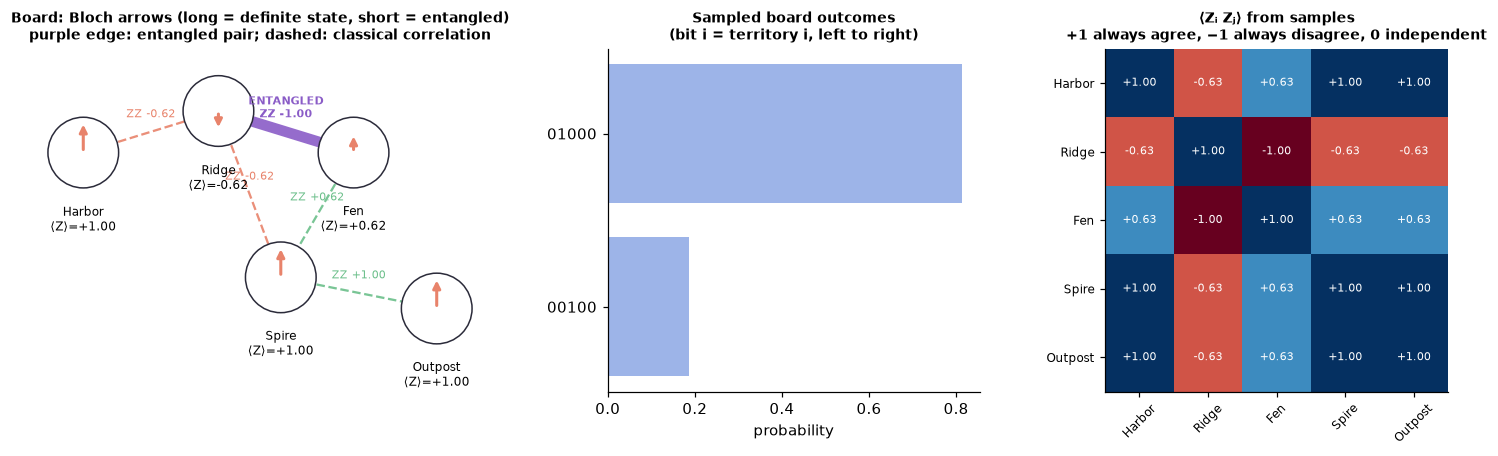

dominant outcome: 01000 | edge agreement score: 0.4 

edge               <ZZ>  |XX|+|YY|  verdict
Harbor-Ridge      -0.62       0.00  no entanglement detected
Ridge-Fen         -1.00       1.57  ENTANGLED (witness > 1)
Ridge-Spire       -0.62       0.00  no entanglement detected
Fen-Spire         +0.62       0.00  no entanglement detected
Spire-Outpost     +1.00       0.00  no entanglement detected

  Harbor   alone: P(1) = 0.00
  Ridge    alone: P(1) = 0.81
  Fen      alone: P(1) = 0.19
  Spire    alone: P(1) = 0.00
  Outpost  alone: P(1) = 0.00


In [18]:
go = result_of(rec_graph)
if rec_graph['status'] == 'completed' and isinstance(go, dict) and go.get('tomography'):
    tomo = go['tomography']; meas = go.get('measurements', [])
    pos = {0: (0, 1), 1: (1.3, 1.4), 2: (2.6, 1), 3: (1.9, -0.2), 4: (3.4, -0.5)}
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), gridspec_kw={'width_ratios': [1.6, 1.1, 1.3]})
    ax = axes[0]; ax.set_aspect('equal'); ax.axis('off')
    rel = tomo.get('relationships', {})
    for a, b in go.get('coupling_map', edges):
        r_ab = rel.get(f'{a},{b}', rel.get(f'{b},{a}', {}))
        zz = r_ab.get('ZZ', 0); wit = abs(r_ab.get('XX', 0)) + abs(r_ab.get('YY', 0))
        ent = wit > 1 + 1e-9
        col = '#8a5cc7' if ent else (C_ACCENT if zz > 0.5 else (C_MEASURED if zz < -0.5 else MUTED))
        ax.plot(*zip(pos[a], pos[b]), color=col, lw=7 if ent else 1.5, zorder=1, alpha=0.9, ls='-' if ent else '--')
        mx, my = (pos[a][0] + pos[b][0]) / 2, (pos[a][1] + pos[b][1]) / 2
        ax.text(mx, my + 0.14, ('ENTANGLED\n' if ent else '') + f'ZZ {zz:+.2f}', fontsize=7, ha='center', color=col,
                weight='bold' if ent else 'normal')
    for q, (x, y) in pos.items():
        bv = tomo['bloch'][str(q)]
        ax.add_patch(Circle((x, y), 0.34, fc='white', ec=INK, lw=1, zorder=2))
        ax.annotate('', xy=(x + 0.3 * bv['X'], y + 0.3 * bv['Z']), xytext=(x, y), zorder=3,
                    arrowprops=dict(arrowstyle='-|>', color=C_MEASURED, lw=2))
        ax.text(x, y - 0.5, f"{names[q]}\n⟨Z⟩={bv['Z']:+.2f}", ha='center', va='top', fontsize=8)
    ax.set_xlim(-0.6, 4); ax.set_ylim(-1.3, 2.0)
    ax.set_title('Board: Bloch arrows (long = definite state, short = entangled)\npurple edge: entangled pair; dashed: classical correlation', fontsize=9)

    ax = axes[1]
    top = meas[:8]
    ax.barh([m['bitstring'] for m in top][::-1], [m['probability'] for m in top][::-1], color=C_TARGET)
    ax.set_xlabel('probability'); ax.set_title('Sampled board outcomes\n(bit i = territory i, left to right)', fontsize=9)

    # correlations measured from samples: qubit-0-LEFTMOST bitstrings (graph-v1 convention)
    shots_g = sum(m['count'] for m in meas)
    M = np.zeros((len(names), len(names)))
    for m in meas:
        s = np.array([1 - 2 * int(ch) for ch in m['bitstring']])       # bit 0 -> +1, bit 1 -> -1
        M += m['count'] * np.outer(s, s)
    M /= max(1, shots_g)
    ax = axes[2]
    im = ax.imshow(M, cmap='RdBu', vmin=-1, vmax=1)
    ax.set_xticks(range(len(names)), names, rotation=45, fontsize=8); ax.set_yticks(range(len(names)), names, fontsize=8)
    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, f'{M[i, j]:+.2f}', ha='center', va='center', fontsize=7, color='white' if abs(M[i, j]) > 0.6 else INK)
    ax.set_title('⟨Zᵢ Zⱼ⟩ from samples\n+1 always agree, −1 always disagree, 0 independent', fontsize=9)
    plt.tight_layout(); plt.show()
    print('dominant outcome:', go.get('dominant_bitstring'), '| edge agreement score:', go.get('edge_agreement_score'), '\n')
    # Entanglement witness: any unentangled (separable) pair obeys |<XX>| + |<YY>| <= 1. A Bell pair reaches 2.
    print(f"{'edge':16s} {'<ZZ>':>6s} {'|XX|+|YY|':>10s}  verdict")
    for k, r in rel.items():
        a, b = map(int, k.split(','))
        w = abs(r.get('XX', 0)) + abs(r.get('YY', 0))
        verdict = 'ENTANGLED (witness > 1)' if w > 1 + 1e-9 else 'no entanglement detected'
        print(f"{names[a] + '-' + names[b]:16s} {r.get('ZZ', 0):+6.2f} {w:10.2f}  {verdict}")
    print()
    for q in range(len(names)):
        p1 = sum(m['count'] for m in meas if m['bitstring'][q] == '1') / max(1, shots_g)
        print(f'  {names[q]:8s} alone: P(1) = {p1:.2f}')
else:
    print('graph-v1 result unavailable:', rec_graph.get('error'))

**Reading the result.** `graph-v1` applies the targets *in order*, each one updating the state the next one starts
from, so a later target can undo an earlier one. Look at what came back (the cells above are the live run):

* **Ridge and Fen are genuinely entangled.** Their `⟨ZZ⟩` is −1: in *every* shot they ended on opposite sides. Yet
  neither one alone is certain (each is a lopsided coin). The witness `|⟨XX⟩| + |⟨YY⟩|` is above 1, which no pair of
  independent qubits can reach, however cleverly prepared: the "opposite fates" are not two hidden notes, they are a
  single shared quantum state. That is a Brisque thread: two undecided battles guaranteed to go opposite ways, and
  measuring one decides the other.
* **Harbor did not stay a 50/50 coin.** Its `X` target was applied first, then the Harbor–Ridge `ZZ` relationship
  pulled it back to a definite state, so Harbor–Ridge ends up merely *correlated*, not entangled. Order matters on
  a graph engine, the same way it matters in the game's many-worlds engine.
* **Outpost and Spire are certain** (`⟨Z⟩ = +1`): classical territories.
* **Look at the arrow lengths.** A qubit in a definite state has a full-length Bloch arrow. Ridge's and Fen's arrows
  are *short*: an entangled qubit, looked at alone, isn't in any pure state of its own. Its information lives in the
  pair, not in either member. That is the strangest, most quantum feature on the board.

This is also why battles don't use `graph-v1`: pairwise targets can't express a general multi-outcome battle
(on 2026-09-25 a 50/44/6 target came back as pure `|00⟩`). Battles go through `tomography-api-v2` with our own exact
circuits (§3); `graph-v1` is the right tool for the board's entanglement network and its visuals (per-territory Bloch
glyphs, per-edge correlation ribbons).

## 6. The pipeline: how Moth reaches a player's browser

Three routes carry quantum results into the game, picked by latency:

| Route | Latency | Where it runs | Used for |
|---|---|---|---|
| **Certified QPU pool** (comet-qrng-v1 on IBM hardware) | 0 ms per collapse | bytes shipped in the static build | default source of every collapse (itch.io, our site, offline) |
| **Live circuits** (tomography-api-v2) | 5 s – 3 min per job | game → Cloudflare Worker (key stays server-side, per-room budget) → Moth | "watch your battle run on a quantum backend" mode; falls back to the pool on timeout |
| **Pre-rendered media** (other Atlas engines) | once, offline | `tools/prerender/` → `public/generated/` + `manifest.json` | VFX masks, textures, SFX; keyed by parameter hash so nothing is re-spent |

Moth only allows browser (CORS) calls from its own platform, so the browser never talks to Moth directly. And the
key is never in the build: `npm run build:itch` refuses to package if it finds one.

In [19]:
gen = REPO / 'public/generated'
manifest_path = gen / 'manifest.json'
entries = []
if manifest_path.exists():
    try:
        mf = json.loads(manifest_path.read_text(encoding='utf-8'))
        entries = mf if isinstance(mf, list) else (mf.get('entries') or mf.get('assets') or mf.get('items') or [{'file': k, **(v if isinstance(v, dict) else {'value': v})} for k, v in mf.items()])
        print(f'manifest.json: {len(entries)} pre-rendered entries (exact params, job id, time recorded for each)')
        for e in entries[:25]:
            if isinstance(e, dict):
                ms = e.get('ms'); 
                print(f"  {str(e.get('engine', '?')):24s} {(str(e.get('file') or ', '.join(e.get('files') or []) or e.get('path') or ''))[:42]:42s} "
                      f"job {str(e.get('job_id', ''))[:8]}  {ms / 1000 if ms else 0:6.1f} s  {str(e.get('why', ''))[:60]}")
    except Exception as ex:
        print('manifest.json present but unreadable:', ex)
else:
    print('No public/generated/manifest.json yet: the pre-render pass writes it; the routes below are what it feeds.')
print('\nFiles shipped in public/generated/:')
for f in sorted(p for p in gen.rglob('*') if p.is_file())[:40]:
    print(f'  {str(f.relative_to(gen)):50s} {f.stat().st_size / 1024:8.1f} KB')

manifest.json: 8 pre-rendered entries (exact params, job id, time recorded for each)
  qpixl-v1                 generated/qpixl-v1/slabs.json              job 0851c255   253.4 s  glitch slab offsets encoded through a noisy fake_marrakesh d
  blur-core-v1             generated/blur-core-v1/static.png          job d6ea5c7a    45.4 s  8 frames of shot-noise "quantum static" (64x64x8 grid, frame
  entanglement-shader-v1   generated/entanglement-shader-v1/peaked.pn job 76358dd0   596.2 s  iridescent BSDF LUT for superposed ground + thread ribbons
  entanglement-shader-v1   generated/entanglement-shader-v1/frustrate job 08eedc18   604.5 s  second LUT (non-monotone colour) for contested metaballs
  telablur-v1              generated/telablur-v1/glitch.webp          job 498d967f    15.9 s  scan bars teleblurred into block noise: screen glitch streak
  blur-core-v1             generated/blur-core-v1/static.png          job 0e4586c6    35.7 s  8 frames of shot-noise "quantum static" (64x64x8 gri

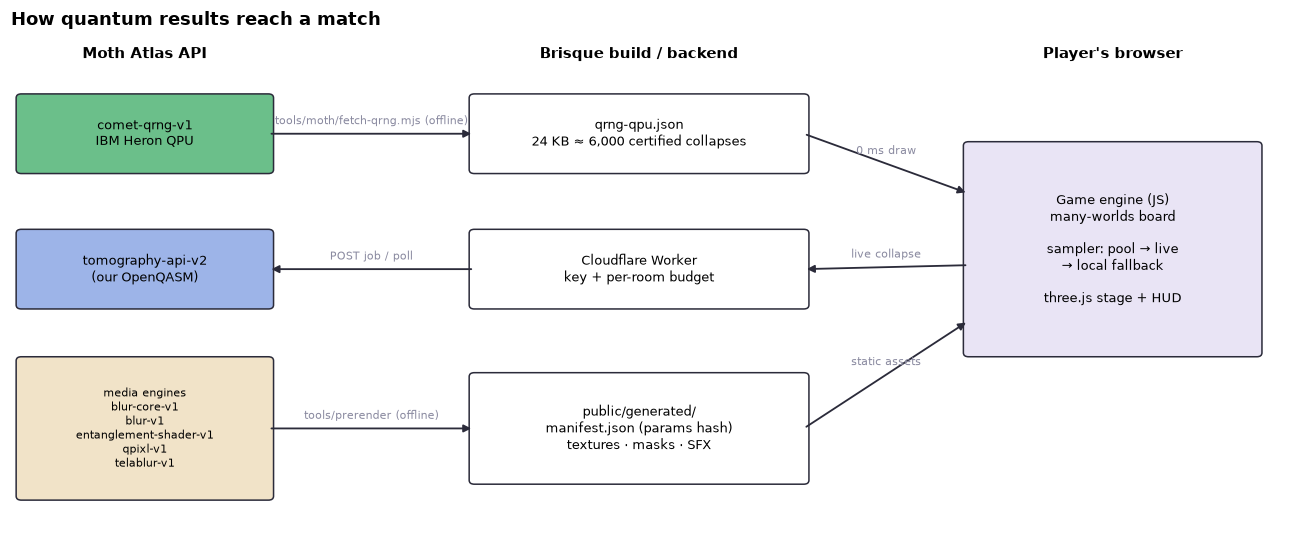

In [20]:
engines_used = sorted({str(e.get('engine')) for e in entries if isinstance(e, dict) and e.get('engine')}) or \
               ['tessa-image-v1', 'blur-v1', 'telablur-v1', 'retrocausal-echo-v1']
fig, ax = plt.subplots(figsize=(12, 5)); ax.axis('off'); ax.set_xlim(-0.1, 12.4); ax.set_ylim(0, 6.2)
def box(x, y, w, h, text, fc, fs=8.5):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.05', fc=fc, ec=INK, lw=1))
    ax.text(x + w / 2, y + h / 2, text, ha='center', va='center', fontsize=fs)
def arrow(x1, y1, x2, y2, label=''):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle='-|>', color=INK, lw=1.2))
    if label: ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.12, label, ha='center', fontsize=7.5, color=MUTED)
ax.text(1.2, 5.9, 'Moth Atlas API', ha='center', weight='bold'); ax.text(6, 5.9, 'Brisque build / backend', ha='center', weight='bold')
ax.text(10.6, 5.9, 'Player\'s browser', ha='center', weight='bold')
box(0, 4.5, 2.4, 0.9, 'comet-qrng-v1\nIBM Heron QPU', C_ACCENT)
box(0, 2.8, 2.4, 0.9, 'tomography-api-v2\n(our OpenQASM)', C_TARGET)
box(0, 0.4, 2.4, 1.7, 'media engines\n' + '\n'.join(engines_used[:5]), '#f1e3c8', 7.5)
box(4.4, 4.5, 3.2, 0.9, 'qrng-qpu.json\n24 KB ≈ 6,000 certified collapses', 'white')
box(4.4, 2.8, 3.2, 0.9, 'Cloudflare Worker\nkey + per-room budget', 'white')
box(4.4, 0.6, 3.2, 1.3, 'public/generated/\nmanifest.json (params hash)\ntextures · masks · SFX', 'white')
box(9.2, 2.2, 2.8, 2.6, 'Game engine (JS)\nmany-worlds board\n\nsampler: pool → live\n→ local fallback\n\nthree.js stage + HUD', '#e9e4f5')
arrow(2.4, 4.95, 4.4, 4.95, 'tools/moth/fetch-qrng.mjs (offline)')
arrow(4.4, 3.25, 2.4, 3.25, 'POST job / poll')
arrow(2.4, 1.25, 4.4, 1.25, 'tools/prerender (offline)')
arrow(7.6, 4.95, 9.2, 4.2, '0 ms draw')
arrow(9.2, 3.3, 7.6, 3.25, 'live collapse')
arrow(7.6, 1.25, 9.2, 2.6, 'static assets')
ax.set_title('How quantum results reach a match', loc='left')
plt.tight_layout(); plt.show()

## 7. Who moves first? `coin-toss-v1`

> **In plain words.** The simplest quantum program there is: put one qubit into an equal superposition with a
> Hadamard gate and measure it. Heads or tails, decided by nature. Brisque uses it for the opening move.

In [21]:
rec_coin = run_job('coin-toss-first-move', 'coin-toss-v1', {'mode': 'emu', 'shots': 1})
cr = result_of(rec_coin)
if rec_coin['status'] == 'completed' and isinstance(cr, dict):
    side = cr.get('output')
    print(f"coin: {side}  (backend {cr.get('backend')}) -> {'Red' if side == 'heads' else 'Blue'} moves first")
else:
    print('coin toss unavailable:', rec_coin.get('error'), '-> the game falls back to a pool draw')

[coin-toss-first-move] replayed from cache (job 6a84fc73-65ab-46e3-b45e-b8df0290ae05, ran 2026-10-05T22:40:49+0300, status completed)
coin: tails  (backend aer) -> Blue moves first


## Summary: every Moth job in this notebook

label                      engine             status     job id                                  queued    proc   total


tomography-3army-1024      tomography-api-v2  error      57115e9b-0959-4972-beeb-0602cf724430         -       -    63.4  (cached)
tomography-3army-1shot     tomography-api-v2  error      595390f2-a2a2-4b1e-aa27-7a0f89a7cdff         -       -    62.7  (cached)
comet-emu-small            comet-qrng-v1      completed  106fea75-4733-4559-8ecc-61746880b8c9       1.4     8.8    14.7  (cached)
graph-entangled-board      graph-v1           completed  297228cb-81ac-4e6d-8642-b29767e794d2       1.4     2.2     6.2  (cached)
coin-toss-first-move       coin-toss-v1       completed  6a84fc73-65ab-46e3-b45e-b8df0290ae05       1.6     1.7     5.7  (cached)


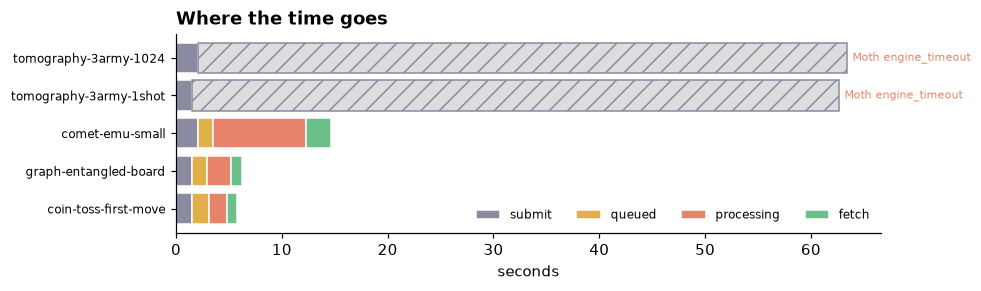


Credits are spent only on first execution; later runs replay notebook/runs/*.json.


In [22]:
print(f"{'label':26s} {'engine':18s} {'status':10s} {'job id':38s} {'queued':>7s} {'proc':>7s} {'total':>7s}")
for r in JOB_LOG:
    t = r.get('timings', {})
    f = lambda k: f"{t[k]:7.1f}" if k in t else '      -'
    print(f"{r['label']:26s} {r['engine']:18s} {r['status']:10s} {str(r.get('job_id')):38s} {f('queued_s')} {f('processing_s')} {f('total_s')}"
          + ('  (cached)' if r.get('replayed') else ''))
done = [r for r in JOB_LOG if r.get('timings', {}).get('total_s')]
if done:
    fig, ax = plt.subplots(figsize=(9, 0.5 + 0.45 * len(done)))
    for i, r in enumerate(done):
        t = r['timings']; left = 0
        for k, col in [('submit_s', MUTED), ('queued_s', C_WARN), ('processing_s', C_MEASURED), ('fetch_s', C_ACCENT)]:
            d = t.get(k, 0); ax.barh(i, d, left=left, color=col, edgecolor='white', label=k[:-2] if i == 0 else None); left += d
        if r['status'] != 'completed':
            ax.barh(i, t['total_s'] - left, left=left, color='#dddddd', hatch='//', edgecolor=MUTED)
            ax.text(t['total_s'] + 0.5, i, 'Moth engine_timeout' if 'engine_timeout' in str(r.get('error')) else 'failed', va='center', fontsize=7, color=C_MEASURED)
    ax.set_yticks(range(len(done)), [r['label'] for r in done], fontsize=8); ax.invert_yaxis()
    ax.set_xlabel('seconds'); ax.legend(frameon=False, fontsize=8, ncol=4, loc='lower right'); ax.set_title('Where the time goes', loc='left')
    plt.tight_layout(); plt.show()
print('\nCredits are spent only on first execution; later runs replay notebook/runs/*.json.')

### What to take away

* **Superposition** is a state with definite *odds* but no definite *outcome*. A Brisque battle stays that way
  until it is measured, and a single RY rotation encodes its odds exactly.
* **Measurement** picks one outcome with the Born-rule probability. Repeat it 1024 times and the odds reappear
  (§3); do it once and you get a single fate (the live collapse).
* **True randomness** is a physical resource. Comet's Bell test (S > 2), min-entropy accounting and Toeplitz
  extraction turn noisy hardware bits into certified uniform bytes, and the game ships those so every collapse is
  decided by a real IBM quantum processor at zero latency.
* **Entanglement** is correlation without predetermined answers: undecided territories whose fates are tied
  together, which is what a Brisque thread is.

Code: `src/shared/quantum/` (game), `tools/moth/` (pool fetch, benchmarks), this notebook (`notebook/`).